In [1]:
# 🏥 Medical Operations Intelligence Dashboard

## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on healthcare operational datasets. It analyzes patient demographics, admissions, treatments, staff, beds, and facilities to understand operational patterns and prepare the data for KPI calculation and dashboard development.

Jupyter Notebook is working!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [6]:
patients = pd.read_csv("../data/processed/cleaned_patients.csv")
admissions = pd.read_csv("../data/processed/cleaned_admissions.csv")
treatments = pd.read_csv("../data/processed/cleaned_treatments.csv")
staff = pd.read_csv("../data/processed/cleaned_staff.csv")
beds = pd.read_csv("../data/processed/cleaned_beds.csv")
facilities = pd.read_csv("../data/processed/cleaned_facilities.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
datasets = {
    "Patients": patients,
    "Admissions": admissions,
    "Treatments": treatments,
    "Staff": staff,
    "Beds": beds,
    "Facilities": facilities
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isnull().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

overview_df = pd.DataFrame(overview)
overview_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Patients,2000,5,0,0
1,Admissions,2000,7,0,0
2,Treatments,2000,6,0,0
3,Staff,2000,6,0,0
4,Beds,2000,5,0,0
5,Facilities,2000,5,0,0


In [8]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    display(df.dtypes)

Patients


patient_id             str
age                  int64
gender                 str
city                   str
registration_date      str
dtype: object

Admissions


admission_id        str
patient_id          str
department          str
admission_date      str
discharge_date      str
admission_type      str
length_of_stay    int64
dtype: object

Treatments


...

staff_id                str
department              str
role                    str
shifts_assigned       int64
shifts_worked         int64
staff_efficiency    float64
dtype: object

Beds


bed_id         str
facility_id    str
department     str
bed_type       str
status         str
dtype: object

Facilities


facility_id        str
facility_name      str
city               str
facility_type      str
total_beds       int64
dtype: object

In [ ]:
## Patient Age Distribution

This chart shows the distribution of patient ages. It helps identify which age groups visit the hospital most frequently.
    

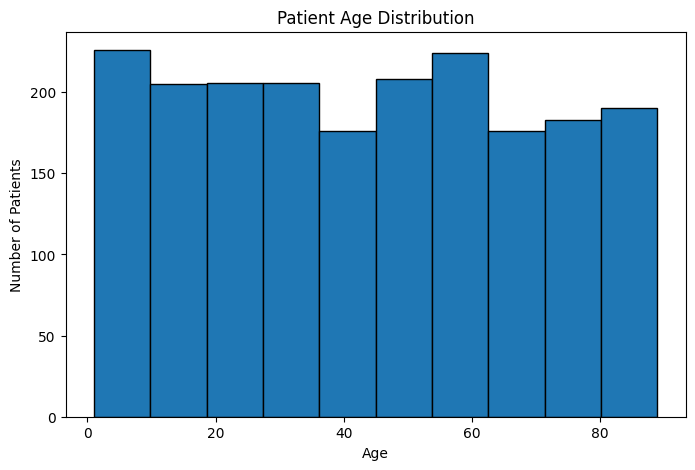

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    patients["age"],
    bins=10,
    edgecolor="black"
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
**Observation:**
- The age distribution shows how patients are spread across different age groups.
- This information helps identify the dominant patient age categories.

In [ ]:
## Gender Distribution

This chart shows the number of patients by gender.

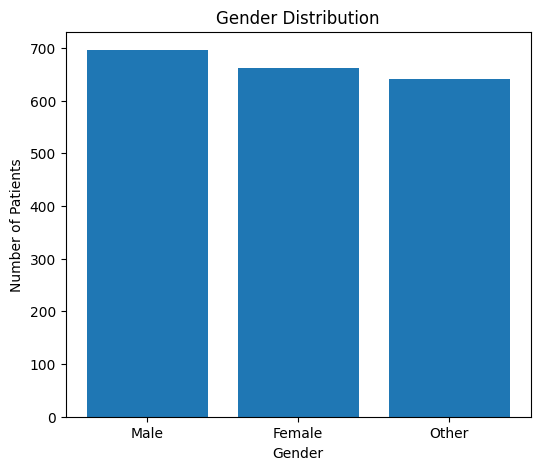

In [11]:
gender_counts = patients["gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
**Observation:**
- The chart compares the number of male, female, and other patients.
- It helps understand the demographic composition of the patient population.

In [ ]:
## Patient Distribution by City

This chart shows the number of registered patients from each city.

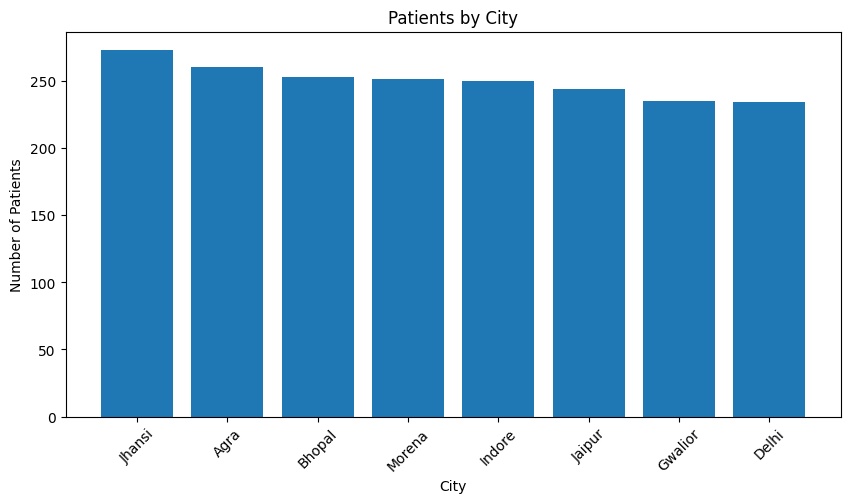

In [12]:
city_counts = patients["city"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    city_counts.index,
    city_counts.values
)

plt.title("Patients by City")
plt.xlabel("City")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

In [ ]:
**Observation:**
- The chart highlights which cities contribute the highest number of patients.
- This information can support healthcare service planning.

In [ ]:
## Admissions by Department

This chart shows the total number of patient admissions across different hospital departments. It helps identify which departments receive the highest patient volume.

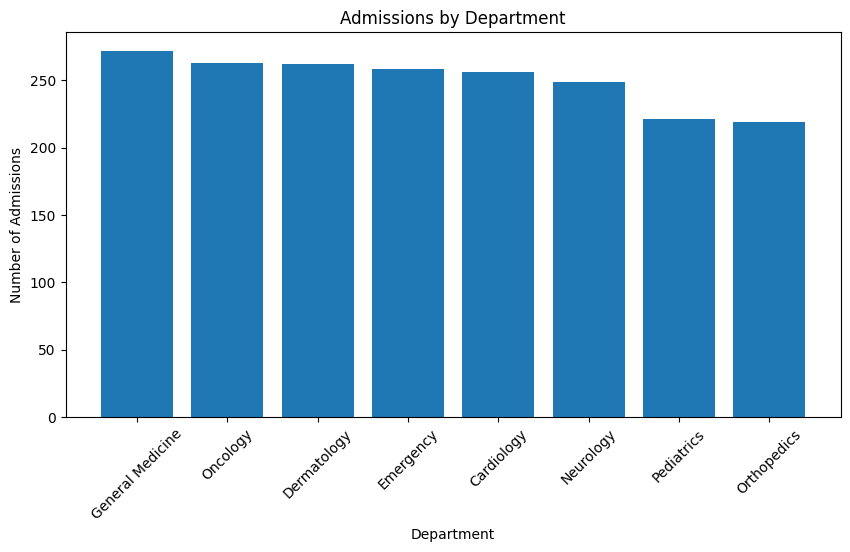

In [14]:
department_counts = admissions["department"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    department_counts.index,
    department_counts.values
)

plt.title("Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)

plt.show()

In [ ]:
**Observation:**

- This chart identifies departments with the highest patient admissions.
- High-admission departments may require additional staff and resources.

In [ ]:
## Admission Type Distribution

This chart compares emergency and planned admissions.

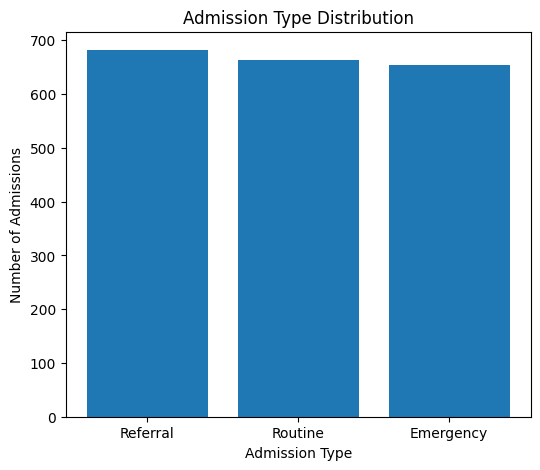

In [15]:
admission_type = admissions["admission_type"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    admission_type.index,
    admission_type.values
)

plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

plt.show()

In [ ]:
**Observation:**

- The chart compares emergency and planned hospital admissions.
- It helps understand hospital service demand.

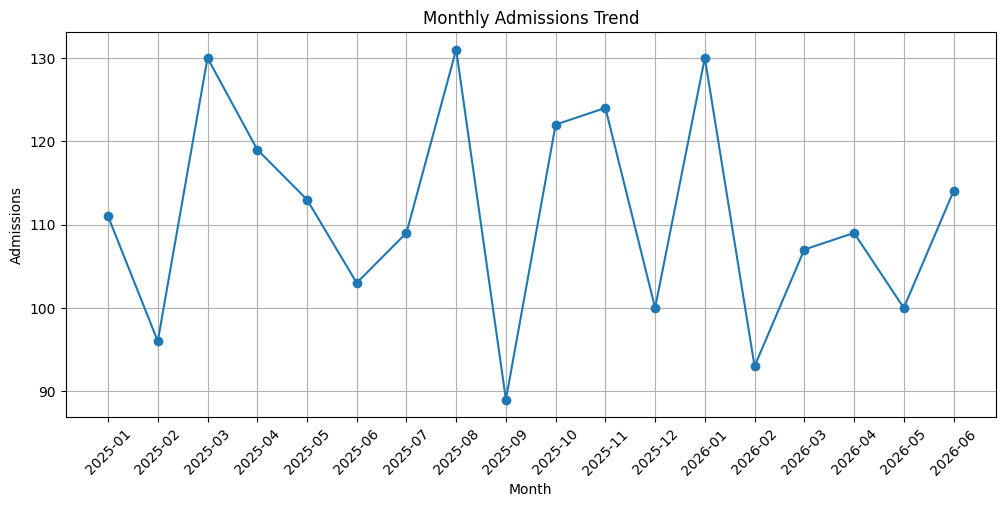

In [16]:
admissions["admission_date"] = pd.to_datetime(admissions["admission_date"])

monthly = admissions.groupby(
    admissions["admission_date"].dt.to_period("M")
).size()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Monthly Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Admissions")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [ ]:
**Observation:**

- The line chart highlights admission trends over time.
- Peaks indicate months with higher patient inflow.

In [17]:
admissions.columns

Index(['admission_id', 'patient_id', 'department', 'admission_date', 'discharge_date', 'admission_type', 'length_of_stay'], dtype='str')

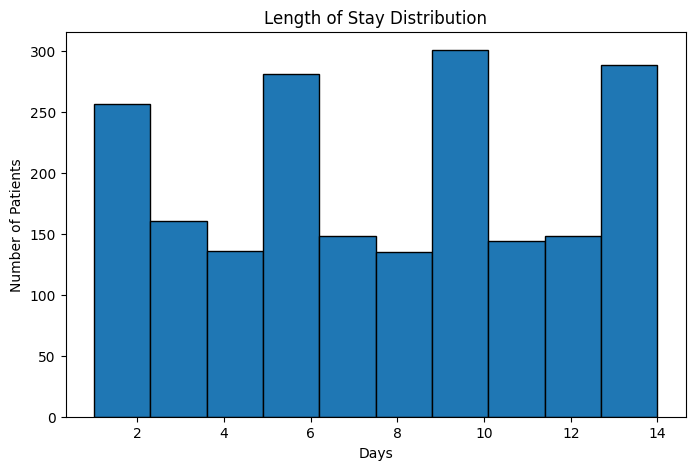

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    admissions["length_of_stay"],
    bins=10,
    edgecolor="black"
)

plt.title("Length of Stay Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
**Observation:**

- The histogram shows how long patients stay in the hospital.
- It helps evaluate bed occupancy and operational efficiency.

In [ ]:
## Treatment Type Distribution

This chart shows the number of treatments performed for each treatment type. It helps identify the most frequently provided healthcare services.

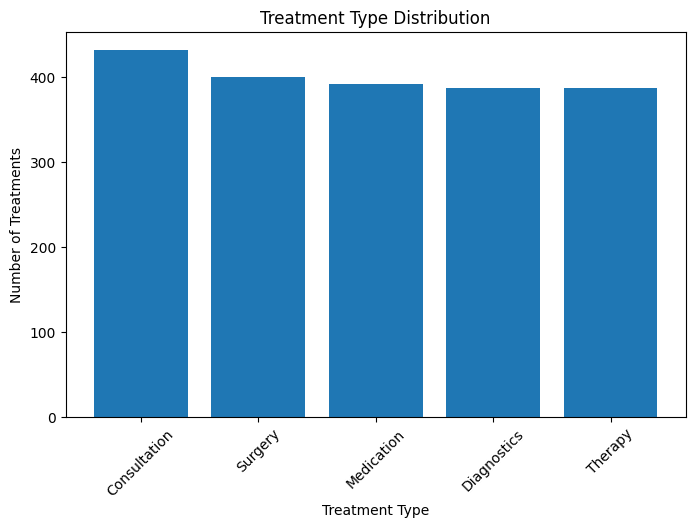

In [20]:
treatment_counts = treatments["treatment_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    treatment_counts.index,
    treatment_counts.values
)

plt.title("Treatment Type Distribution")
plt.xlabel("Treatment Type")
plt.ylabel("Number of Treatments")

plt.xticks(rotation=45)

plt.show()

In [ ]:
**Observation:**

- This chart shows the frequency of each treatment type.
- The most common treatment indicates the highest service demand.

In [ ]:
## Treatment Status Distribution

This chart shows the current status of treatments such as Completed, Pending, or In Progress.

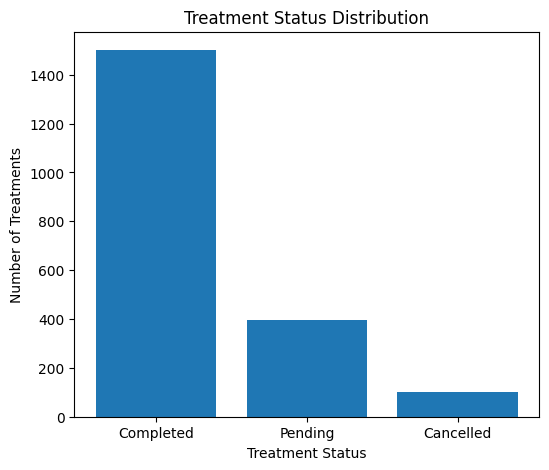

In [21]:
status_counts = treatments["treatment_status"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Treatment Status Distribution")
plt.xlabel("Treatment Status")
plt.ylabel("Number of Treatments")

plt.show()

In [ ]:
**Observation:**

- Most treatments should ideally be marked as **Completed**.
- Pending or In Progress treatments help identify operational workload.

In [ ]:
## Monthly Treatment Trend

This chart displays the monthly trend in treatment demand.

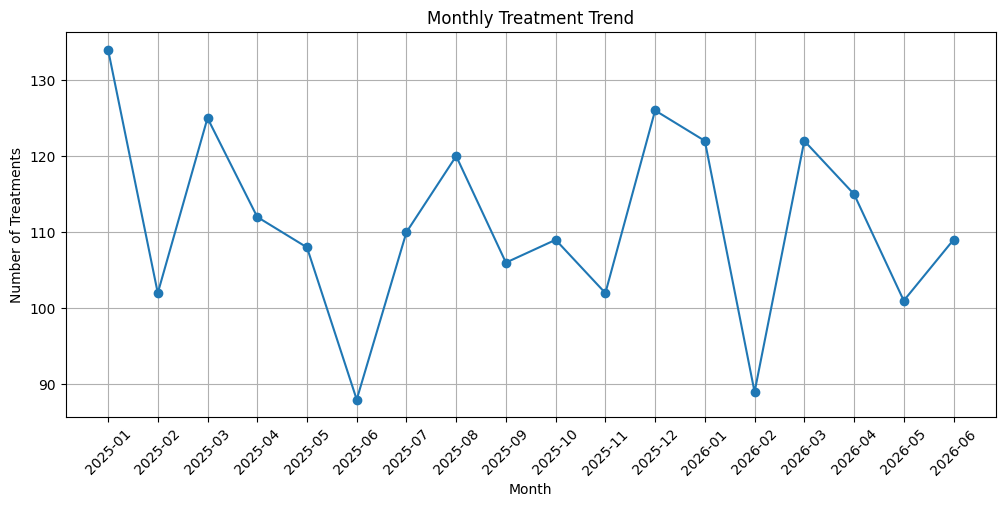

In [22]:
treatments["treatment_date"] = pd.to_datetime(treatments["treatment_date"])

monthly_treatments = treatments.groupby(
    treatments["treatment_date"].dt.to_period("M")
).size()

monthly_treatments.index = monthly_treatments.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_treatments.index,
    monthly_treatments.values,
    marker="o"
)

plt.title("Monthly Treatment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Treatments")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [ ]:
**Observation:**

- This trend shows how treatment demand changes over time.
- Peak months may require additional healthcare resources.

In [ ]:
## Staff Distribution by Department

This chart shows the number of staff members working in each hospital department. It helps evaluate workforce allocation across departments.

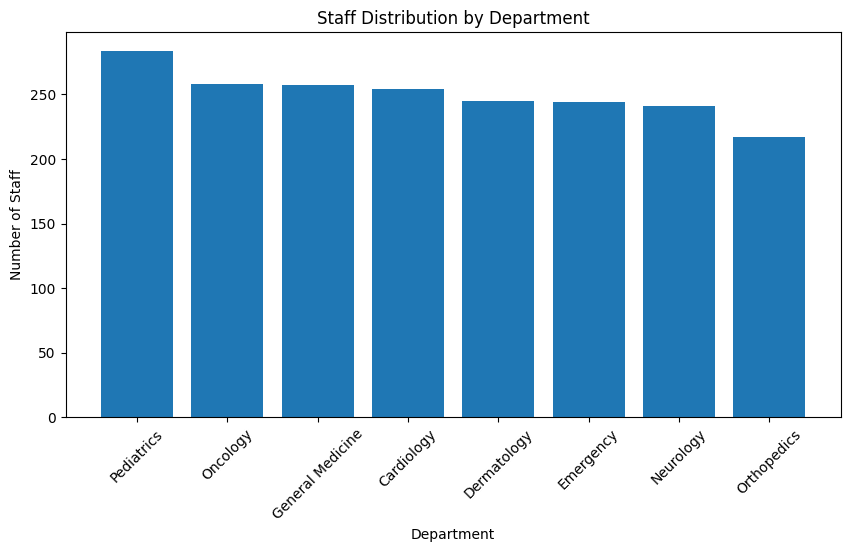

In [23]:
staff_department = staff["department"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    staff_department.index,
    staff_department.values
)

plt.title("Staff Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Staff")

plt.xticks(rotation=45)

plt.show()

In [ ]:
**Observation:**

- This chart shows how staff are distributed across departments.
- Departments with more staff generally support higher patient workloads.

In [24]:
staff.columns

Index(['staff_id', 'department', 'role', 'shifts_assigned', 'shifts_worked', 'staff_efficiency'], dtype='str')

In [ ]:
## Staff Efficiency Distribution

This histogram displays the distribution of staff efficiency scores. It helps evaluate workforce performance.

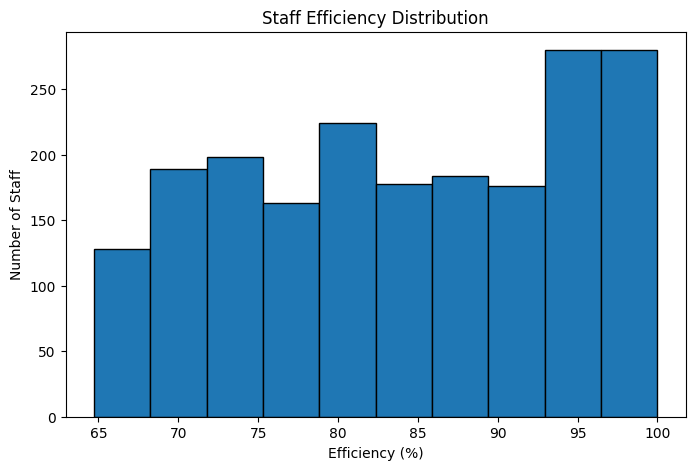

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    staff["staff_efficiency"],
    bins=10,
    edgecolor="black"
)

plt.title("Staff Efficiency Distribution")
plt.xlabel("Efficiency (%)")
plt.ylabel("Number of Staff")

plt.show()

In [ ]:
**Observation:**

- Most staff members should have efficiency values clustered around the average.
- This chart helps identify overall workforce performance.

In [26]:
staff.columns

Index(['staff_id', 'department', 'role', 'shifts_assigned', 'shifts_worked', 'staff_efficiency'], dtype='str')

In [ ]:
## Staff Distribution by Role

This chart shows the number of staff members in different roles such as doctors, nurses, technicians, and administrative staff.

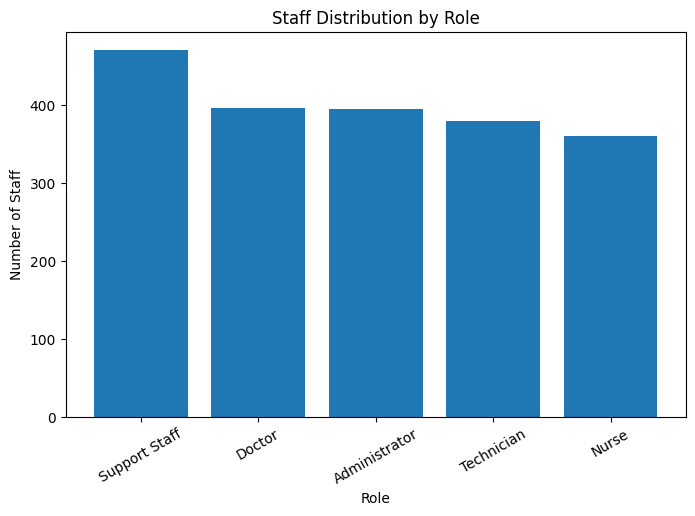

In [27]:
role_counts = staff["role"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    role_counts.index,
    role_counts.values
)

plt.title("Staff Distribution by Role")
plt.xlabel("Role")
plt.ylabel("Number of Staff")

plt.xticks(rotation=30)

plt.show()

In [ ]:
**Observation:**

- This chart shows the composition of the hospital workforce.
- Understanding the distribution of roles helps evaluate staffing balance across clinical and non-clinical functions.

In [ ]:
## Bed Occupancy Status

This chart shows the proportion of occupied and available beds in the hospital. It helps evaluate hospital capacity utilization.

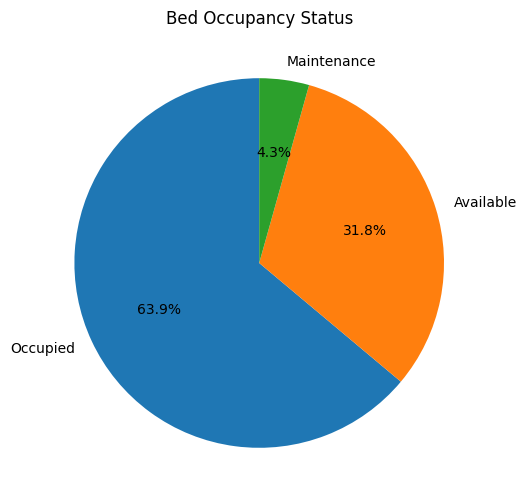

In [28]:
bed_status = beds["status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    bed_status.values,
    labels=bed_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Bed Occupancy Status")

plt.show()

In [ ]:
**Observation:**

- This chart shows the percentage of occupied and available beds.
- A high occupancy rate indicates greater demand for hospital resources.

In [ ]:
## Bed Distribution by Department

This chart shows how beds are allocated across different hospital departments.

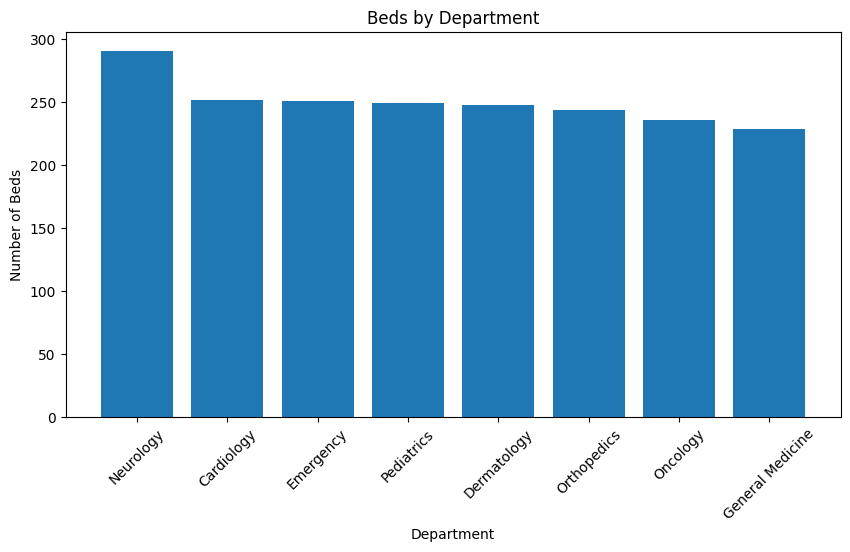

In [29]:
bed_department = beds["department"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    bed_department.index,
    bed_department.values
)

plt.title("Beds by Department")
plt.xlabel("Department")
plt.ylabel("Number of Beds")

plt.xticks(rotation=45)

plt.show()

In [ ]:
**Observation:**

- The chart shows bed allocation across hospital departments.
- Departments with more beds generally support higher patient volumes.

In [30]:
bed_status

status
Occupied       1278
Available       635
Maintenance      87
Name: count, dtype: int64

In [ ]:
## Facility Capacity

This chart shows the capacity of each healthcare facility. It helps compare the size and service capability of different facilities.

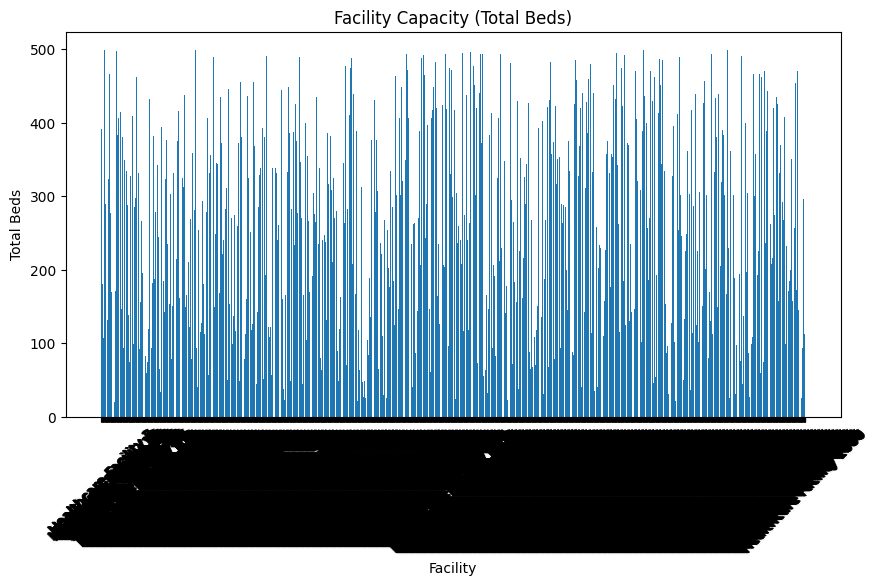

In [38]:
plt.figure(figsize=(10,5))

plt.bar(
    facilities["facility_name"],
    facilities["total_beds"]
)

plt.title("Facility Capacity (Total Beds)")
plt.xlabel("Facility")
plt.ylabel("Total Beds")

plt.xticks(rotation=45)

plt.show()

In [ ]:
## Facility Type Distribution

This chart shows the distribution of different healthcare facility types in the dataset.

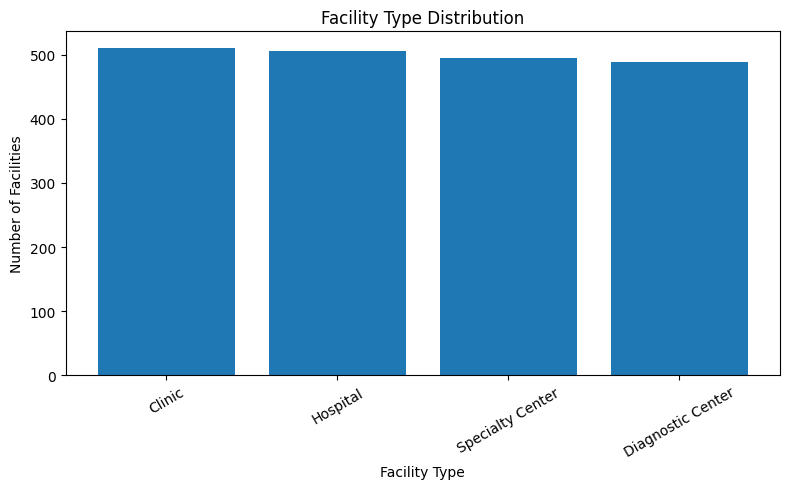

In [39]:
facility_type = facilities["facility_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    facility_type.index,
    facility_type.values
)

plt.title("Facility Type Distribution")
plt.xlabel("Facility Type")
plt.ylabel("Number of Facilities")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
**Observation:**

- The chart shows the number of facilities in each facility type.
- It helps understand the composition of healthcare infrastructure.

In [ ]:
## Facilities by City

This chart shows the distribution of healthcare facilities across different cities. It helps understand the geographic spread of healthcare services.

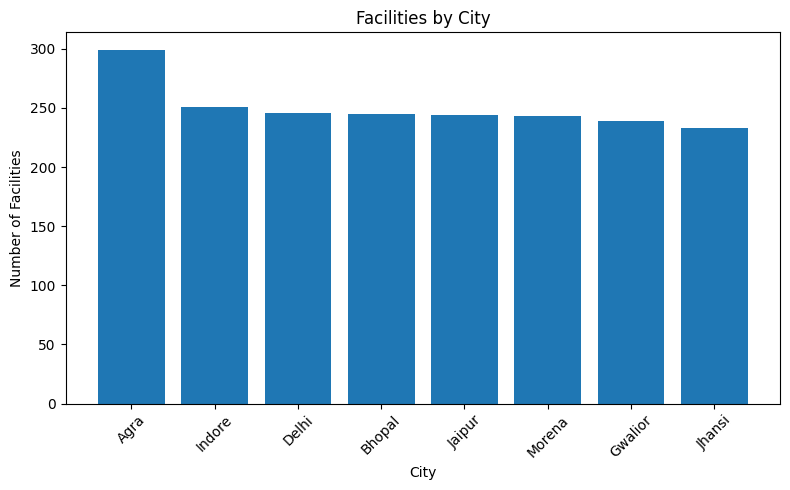

In [40]:
city_counts = facilities["city"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    city_counts.index,
    city_counts.values
)

plt.title("Facilities by City")
plt.xlabel("City")
plt.ylabel("Number of Facilities")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
**Observation:**

- The chart shows how healthcare facilities are distributed across different cities.
- Cities with more facilities generally have greater healthcare service availability.
- This information is useful for planning healthcare coverage and identifying areas that may need additional facilities.

In [ ]:
# Correlation Analysis

This section examines the relationships between important numerical variables in the healthcare datasets.

In [41]:
numeric_df = pd.DataFrame({
    "Age": patients["age"],
    "Length_of_Stay": admissions["length_of_stay"],
    "Staff_Efficiency": staff["staff_efficiency"],
    "Total_Beds": facilities["total_beds"]
})

correlation = numeric_df.corr()

correlation

,Age,Length_of_Stay,Staff_Efficiency,Total_Beds
Age,1.000000,-0.015487,-0.013244,-0.039998
Length_of_Stay,-0.015487,1.000000,-0.026657,0.041018
Staff_Efficiency,-0.013244,-0.026657,1.000000,0.018435
Total_Beds,-0.039998,0.041018,0.018435,1.000000


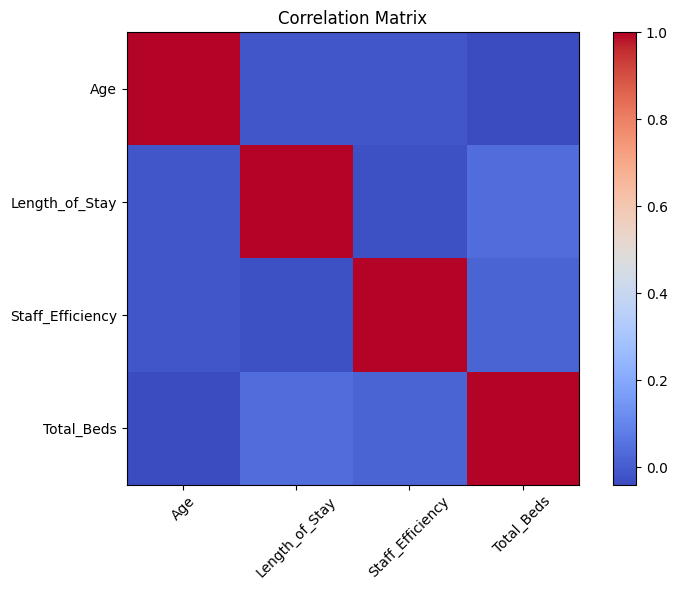

In [42]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [ ]:
**Observation:**

- The correlation matrix shows the relationship between numerical variables.
- Values close to **1** indicate a strong positive relationship.
- Values close to **-1** indicate a strong negative relationship.
- Values near **0** indicate little or no linear relationship.

In [ ]:
# Key Insights

Based on the exploratory data analysis, the following operational insights were identified:

- The hospital serves patients across multiple cities and departments.
- General Medicine records one of the highest patient workloads.
- Consultation is the most frequently performed treatment.
- Emergency and planned admissions both contribute significantly to hospital operations.
- Bed occupancy indicates active utilization of healthcare resources.
- Staff efficiency remains consistently high, supporting effective hospital operations.
- Facility distribution highlights healthcare service availability across different cities.

These findings support operational planning, resource allocation, and executive decision-making.

In [ ]:
# Conclusion

The exploratory data analysis successfully examined patient demographics, hospital admissions, treatment demand, workforce utilization, bed occupancy, and facility information.

The analysis identified operational trends and resource utilization patterns that can assist healthcare administrators in making informed decisions.

The cleaned datasets and analytical insights produced in this phase provide a strong foundation for the next stages of the project, including interactive dashboards, patient flow intelligence, and executive reporting.